In [11]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def create_map_np():
    map_data = np.zeros((10, 10), dtype=int)
    obstacles = [(0, 2), (0, 3),(1, 2), (1, 3), (2, 2), (2, 3), (3, 2), (3, 3),
                 (1, 7), (1, 8), (1, 9),
                 (4, 5), (4, 6), (5, 5), (5, 6), (6, 5), (6, 6),
                 (7, 1), (7, 2), (8, 1), (8, 2),
                 (7, 8), (8, 8),
                 (9, 4), (9, 5)]
    for i, j in obstacles:
        map_data[i, j] = 1
    return map_data

def visualize_map(map_data, path=None, title="Map"):
    plt.figure(figsize=(8, 8))
    plt.imshow(map_data, cmap='binary')
    for i in range(map_data.shape[0] + 1):
        plt.axhline(i - 0.5, color='gray', linestyle='-', alpha=0.3)
        plt.axvline(i - 0.5, color='gray', linestyle='-', alpha=0.3)
    for i in range(map_data.shape[0]):
        for j in range(map_data.shape[1]):
            node_num = i * map_data.shape[1] + j + 1
            plt.text(j, i, f'{node_num}', ha='center', va='center', 
                     color='white' if map_data[i, j] == 1 else 'black')
    if path:
        path_coords = []
        for node in path:
            row = (node - 1) // map_data.shape[1]
            col = (node - 1) % map_data.shape[1]
            path_coords.append((col, row))
        x_coords = [x for x, y in path_coords]
        y_coords = [y for x, y in path_coords]
        plt.plot(x_coords, y_coords, 'r-', linewidth=2)
        plt.plot(x_coords, y_coords, 'bo', markersize=8)
        plt.plot(x_coords[0], y_coords[0], 'go', markersize=10)
        plt.plot(x_coords[-1], y_coords[-1], 'mo', markersize=10)
    plt.title(title)
    plt.grid(True)
    plt.xticks(range(map_data.shape[1]))
    plt.yticks(range(map_data.shape[0]))
    plt.show()

def hash_path(path):
    return hash(tuple(path))

def bresenham_line(x0, y0, x1, y1):
    points = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    x, y = x0, y0
    sx = -1 if x0 > x1 else 1
    sy = -1 if y0 > y1 else 1
    if dx > dy:
        err = dx / 2.0
        while x != x1:
            points.append((x, y))
            err -= dy
            if err < 0:
                y += sy
                err += dx
            x += sx
        points.append((x, y))
    else:
        err = dy / 2.0
        while y != y1:
            points.append((x, y))
            err -= dx
            if err < 0:
                x += sx
                err += dy
            y += sy
        points.append((x, y))
    return points

In [12]:
def random_walk_np(start, goal, map_data, max_steps=60):
    current = start
    path = [current]
    steps = 0
    visited = set([current])
    while current != goal and steps < max_steps:
        row, col = (current - 1) // 10, (current - 1) % 10
        possible_moves = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                new_row, new_col = row + dr, col + dc
                if (0 <= new_row < 10 and 0 <= new_col < 10 and map_data[new_row, new_col] == 0):
                    new_node = new_row * 10 + new_col + 1
                    if new_node not in visited:
                        possible_moves.append(new_node)
        if not possible_moves:
            if len(path) <= 1:
                return None
            path.pop()
            current = path[-1]
            steps += 1
            continue
        if goal in possible_moves:
            path.append(goal)
            break
        next_node = random.choice(possible_moves)
        path.append(next_node)
        visited.add(next_node)
        current = next_node
        steps += 1
    if current != goal:
        return None
    return path

def repair_path(path, map_data):
    # 장애물 위 구간만 BFS로 우회(최소화)
    def bfs_path(start, goal, map_data):
        from collections import deque
        queue = deque()
        queue.append((start, [start]))
        visited = set([start])
        while queue:
            current, p = queue.popleft()
            if current == goal:
                return p
            row, col = (current - 1) // 10, (current - 1) % 10
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    if dr == 0 and dc == 0:
                        continue
                    new_row, new_col = row + dr, col + dc
                    if 0 <= new_row < 10 and 0 <= new_col < 10 and map_data[new_row, new_col] == 0:
                        next_node = new_row * 10 + new_col + 1
                        if next_node not in visited:
                            visited.add(next_node)
                            queue.append((next_node, p + [next_node]))
        return None
    fixed = [path[0]]
    for i in range(1, len(path)):
        prev = fixed[-1]
        curr = path[i]
        r0, c0 = (prev - 1) // 10, (prev - 1) % 10
        r1, c1 = (curr - 1) // 10, (curr - 1) % 10
        blocked = False
        for rr, cc in bresenham_line(r0, c0, r1, c1):
            if map_data[rr, cc] == 1:
                blocked = True
                break
        if not blocked:
            fixed.append(curr)
        else:
            sub = bfs_path(prev, curr, map_data)
            if sub is None:
                return None
            fixed += sub[1:]
    return fixed

def initialize_population_np(start, goal, map_data, pop_size=10):
    population = []
    hash_set = set()
    tries = 0
    while len(population) < pop_size and tries < pop_size * 200:
        path = random_walk_np(start, goal, map_data)
        if path:
            h = hash_path(path)
            if h not in hash_set:
                population.append(path)
                hash_set.add(h)
        tries += 1
    # 부족한 경우 BFS로 채움
    while len(population) < pop_size:
        from collections import deque
        def bfs_path(start, goal, map_data):
            queue = deque()
            queue.append((start, [start]))
            visited = set([start])
            while queue:
                current, p = queue.popleft()
                if current == goal:
                    return p
                row, col = (current - 1) // 10, (current - 1) % 10
                for dr in [-1, 0, 1]:
                    for dc in [-1, 0, 1]:
                        if dr == 0 and dc == 0:
                            continue
                        new_row, new_col = row + dr, col + dc
                        if 0 <= new_row < 10 and 0 <= new_col < 10 and map_data[new_row, new_col] == 0:
                            next_node = new_row * 10 + new_col + 1
                            if next_node not in visited:
                                visited.add(next_node)
                                queue.append((next_node, p + [next_node]))
            return None
        path = bfs_path(start, goal, map_data)
        if path:
            h = hash_path(path)
            if h not in hash_set:
                population.append(path)
                hash_set.add(h)
        else:
            population.append([start, goal])
    return population

In [13]:
class PathEvaluator:
    def __init__(self, map_data):
        self.map_data = map_data

    def evaluate(self, path):
        for i in range(len(path) - 1):
            r0, c0 = (path[i] - 1) // 10, (path[i] - 1) % 10
            r1, c1 = (path[i+1] - 1) // 10, (path[i+1] - 1) % 10
            for rr, cc in bresenham_line(r0, c0, r1, c1):
                if self.map_data[rr, cc] == 1:
                    return float('inf')
        dr = []
        dc = []
        for i in range(len(path)-1):
            r0, c0 = (path[i] - 1) // 10, (path[i] - 1) % 10
            r1, c1 = (path[i+1] - 1) // 10, (path[i+1] - 1) % 10
            dr.append(r1 - r0)
            dc.append(c1 - c0)
        dist = np.sqrt(np.array(dr) ** 2 + np.array(dc) ** 2)
        return dist.sum()

    def batch_evaluate(self, population):
        return [self.evaluate(path) for path in population]

In [14]:
class ProposedGA_Fast:
    def __init__(self, map_data, start, goal, pop_size=10, max_gen=15):
        self.map_data = map_data
        self.start = start
        self.goal = goal
        self.pop_size = pop_size
        self.max_gen = max_gen
        self.crossover_rate = 0.5
        self.mutation_rate = 0.2
        self.shortcut_rate = 0.3
        self.population = initialize_population_np(start, goal, map_data, pop_size)
        self.evaluator = PathEvaluator(map_data)
        self.best_path = None
        self.best_distance = float('inf')
        self.best_history = []

    def crossover(self, path1, path2):
        minlen = min(len(path1), len(path2))
        if minlen <= 2:
            return path1.copy()
        point = random.randint(1, minlen - 2)
        new_path = path1[:point] + path2[point:]
        dedup_path = []
        seen = set()
        for n in new_path:
            if n not in seen:
                dedup_path.append(n)
                seen.add(n)
        if dedup_path[-1] != self.goal:
            dedup_path.append(self.goal)
        repaired = repair_path(dedup_path, self.map_data)
        return repaired if repaired is not None else [self.start, self.goal]

    def mutation(self, path):
        if len(path) <= 2:
            return path.copy()
        point = random.randint(1, len(path) - 2)
        row, col = (path[point] - 1) // 10, (path[point] - 1) % 10
        possible_nodes = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                new_row, new_col = row + dr, col + dc
                new_node = new_row * 10 + new_col + 1
                if (0 <= new_row < 10 and 0 <= new_col < 10 and 
                    self.map_data[new_row, new_col] == 0 and new_node not in path):
                    possible_nodes.append(new_node)
        if not possible_nodes:
            return path.copy()
        new_path = path.copy()
        new_path[point] = random.choice(possible_nodes)
        dedup_path = []
        seen = set()
        for n in new_path:
            if n not in seen:
                dedup_path.append(n)
                seen.add(n)
        if dedup_path[-1] != self.goal:
            dedup_path.append(self.goal)
        repaired = repair_path(dedup_path, self.map_data)
        return repaired if repaired is not None else [self.start, self.goal]

    def shortcut(self, path):
        if len(path) <= 3:
            return path.copy()
        l = len(path)
        idx1, idx2 = sorted(random.sample(range(l), 2))
        if idx2 - idx1 > 1:
            new_path = path[:idx1+1] + path[idx2:]
            dedup_path = []
            seen = set()
            for n in new_path:
                if n not in seen:
                    dedup_path.append(n)
                    seen.add(n)
            if dedup_path[-1] != self.goal:
                dedup_path.append(self.goal)
            repaired = repair_path(dedup_path, self.map_data)
            return repaired if repaired is not None else [self.start, self.goal]
        return path.copy()

    def evolve(self):
        for gen in tqdm(range(self.max_gen), desc="ProposedGA 진행"):
            uniq_hash = set()
            uniq_pop = []
            for path in self.population:
                h = hash_path(path)
                if h not in uniq_hash:
                    uniq_pop.append(path)
                    uniq_hash.add(h)
            if not uniq_pop:
                uniq_pop.append([self.start, self.goal])
            self.population = uniq_pop

            new_population = []
            tries = 0
            while len(new_population) < self.pop_size and tries < self.pop_size * 5:
                parent = random.choice(self.population)
                child = parent.copy()
                if random.random() < self.crossover_rate:
                    parent2 = random.choice(self.population)
                    child = self.crossover(child, parent2)
                if random.random() < self.mutation_rate:
                    child = self.mutation(child)
                if random.random() < self.shortcut_rate:
                    child = self.shortcut(child)
                h = hash_path(child)
                if h not in uniq_hash and self.evaluator.evaluate(child) != float('inf'):
                    new_population.append(child)
                    uniq_hash.add(h)
                tries += 1

            if not new_population:
                new_population.append([self.start, self.goal])

            all_population = self.population + new_population
            valid_population = [p for p in all_population if self.evaluator.evaluate(p) != float('inf')]
            if not valid_population:
                valid_population = [[self.start, self.goal]]
            scores = self.evaluator.batch_evaluate(valid_population)
            scores_np = np.array(scores)
            sorted_indices = np.argsort(scores_np)
            self.population = [valid_population[i] for i in sorted_indices[:self.pop_size]]
            current_best = scores_np[sorted_indices[0]]
            current_mean = scores_np[:self.pop_size].mean()
            if current_best < self.best_distance:
                self.best_path = self.population[0]
                self.best_distance = current_best
            self.best_history.append(self.best_distance)
            if gen % 3 == 0 or gen == self.max_gen - 1:
                print(f"[세대 {gen+1:02d}] 최단 거리: {current_best:.2f} / 평균 거리: {current_mean:.2f} / 고유경로수: {len(self.population)}")
        return self.best_path, self.best_distance

ProposedGA 진행:   0%|          | 0/1 [00:00<?, ?it/s]

[세대 01] 최단 거리: 13.90 / 평균 거리: 13.90 / 고유경로수: 1
ProposedGA(빠름) 최단 거리: 13.90


c:\Users\brigh\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48736 (\N{HANGUL SYLLABLE BBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\brigh\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\brigh\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\brigh\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\brigh\AppData\Local\Programs\Python\Python311\Lib\site-packag

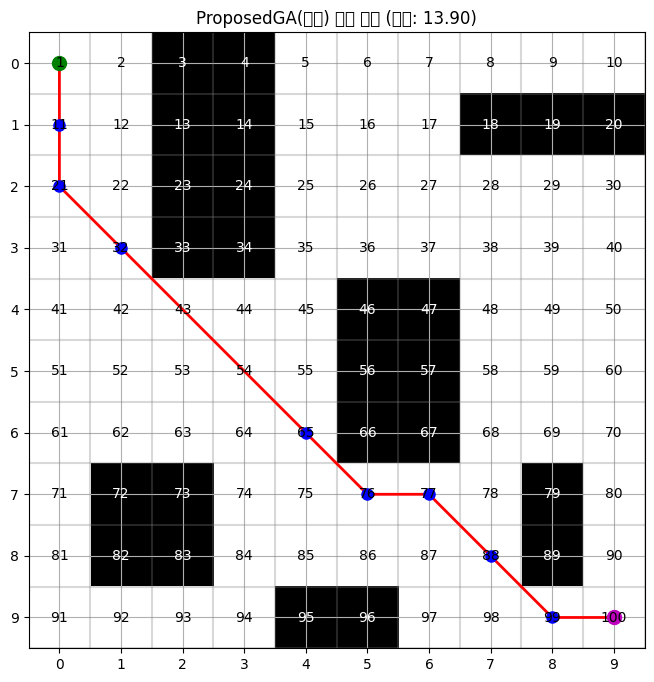

c:\Users\brigh\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\brigh\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\brigh\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\brigh\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\brigh\AppData\Local\Programs\Python\Python311\Lib\site-packages

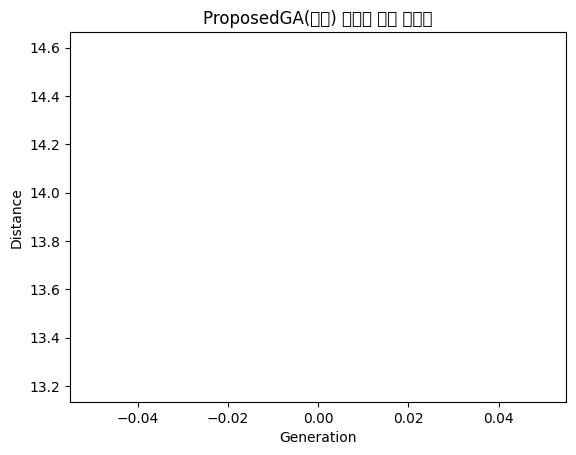

In [15]:
map_data = create_map_np()
start, goal = 1, 100
pop_size, max_gen = 1,1

ga = ProposedGA_Fast(map_data, start, goal, pop_size=pop_size, max_gen=max_gen)
best_path, best_dist = ga.evolve()

print(f"ProposedGA(빠름) 최단 거리: {best_dist:.2f}")
visualize_map(map_data, best_path, title=f"ProposedGA(빠름) 최종 경로 (거리: {best_dist:.2f})")
import matplotlib.pyplot as plt
plt.plot(ga.best_history)
plt.title("ProposedGA(빠름) 세대별 수렴 그래프")
plt.xlabel("Generation")
plt.ylabel("Distance")
plt.show()